# Welcome to Colab!

In [201]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Files in session:")
print(os.listdir())

Files in session:
['.config', 'check_answer.py', 'mouse_velocities.csv', 'sample_data']


In [202]:
df = pd.read_csv("/content/mouse_velocities.csv")
print("Shape:", df.shape)
print("Columns:", list(df.columns))
print(df.head())
print("\nDtypes:\n", df.dtypes)

Shape: (9978, 3)
Columns: ['timestamp', 'velocity_x', 'velocity_y']
                    timestamp  velocity_x  velocity_y
0  2025-08-11T10:48:43.925977   -0.831047   -4.192823
1  2025-08-11T10:48:43.940977    1.319054   -6.052437
2  2025-08-11T10:48:43.955977   -1.135314   -3.955116
3  2025-08-11T10:48:43.970977   -2.590931   -6.419663
4  2025-08-11T10:48:43.985977   -2.260600   -2.485481

Dtypes:
 timestamp      object
velocity_x    float64
velocity_y    float64
dtype: object


In [203]:
# Coerce all columns to numeric where possible (non-numeric becomes NaN)
df_num = df.apply(pd.to_numeric, errors="coerce")

# Drop any rows that became NaN in the first two columns (velocities)
df_num = df_num.dropna(subset=[df_num.columns[0], df_num.columns[1]]).reset_index(drop=True)

print("After numeric conversion:", df_num.shape)
print(df_num.head())
print("\nDtypes:\n", df_num.dtypes)

After numeric conversion: (0, 3)
Empty DataFrame
Columns: [timestamp, velocity_x, velocity_y]
Index: []

Dtypes:
 timestamp     float64
velocity_x    float64
velocity_y    float64
dtype: object


In [204]:
dt = 0.015  # 15ms per README

vx = df['velocity_x'].to_numpy()
vy = df['velocity_y'].to_numpy()

x = np.cumsum(vx * dt)
y = np.cumsum(vy * dt)

print("x/y length:", len(x), len(y))

x/y length: 9978 9978


In [205]:
print(len(x), len(y), x[:3], y[:3])

9978 9978 [-0.01246571  0.0073201  -0.00970961] [-0.06289235 -0.1536789  -0.21300565]


In [206]:
%matplotlib inline

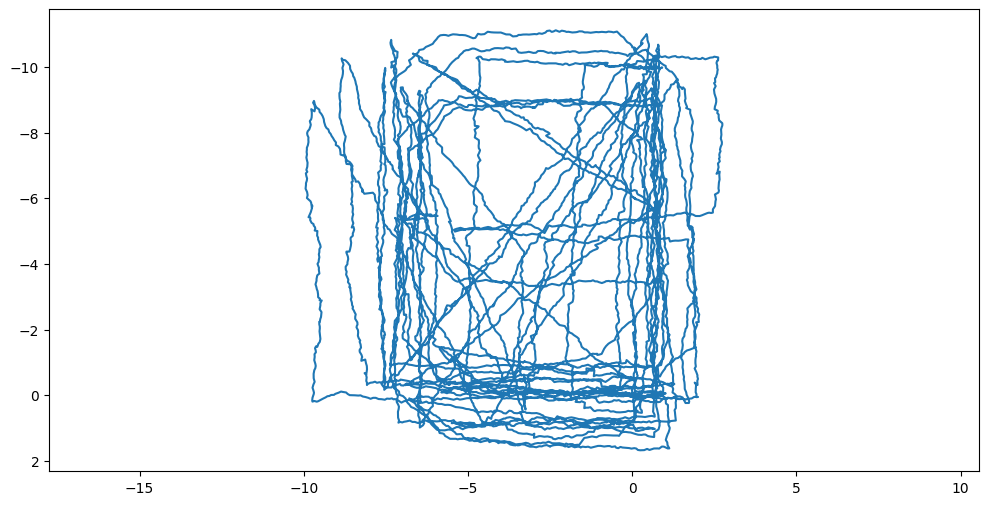

In [207]:
plt.figure(figsize=(12,6)); plt.plot(-x, y); plt.gca().invert_yaxis(); plt.axis("equal"); plt.show()

In [208]:
import matplotlib.pyplot as plt

plt.figure()

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

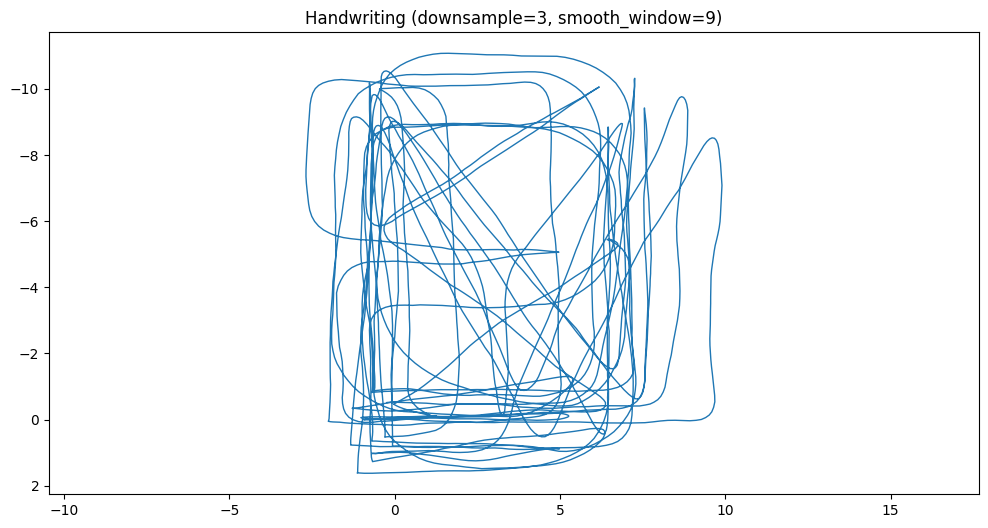

In [209]:
step = 3  # try 2, 3, 5, 8
xs, ys = x[::step], y[::step]

# optional smoothing (try window 5, 9, 15)
window = 9
if window > 1:
    xs = pd.Series(xs).rolling(window, center=True, min_periods=1).mean().to_numpy()
    ys = pd.Series(ys).rolling(window, center=True, min_periods=1).mean().to_numpy()

plt.figure(figsize=(12, 6))
plt.plot(xs, ys, linewidth=1)
plt.gca().invert_yaxis()
plt.axis("equal")
plt.title(f"Handwriting (downsample={step}, smooth_window={window})")
plt.show()

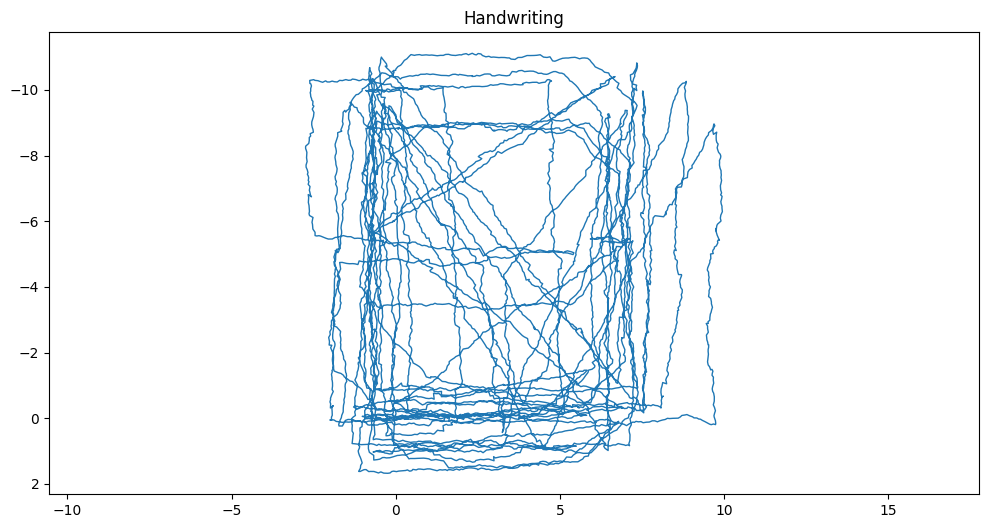

In [210]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(x, y, linewidth=1)
plt.gca().invert_yaxis()   # try removing if upside down
plt.axis("equal")
plt.title("Handwriting")
plt.show()

In [211]:
answer = "YASWANTH REDDY SUDHA"
print("CALL ME SUDHA", answer)

CALL ME SUDHA YASWANTH REDDY SUDHA


In [212]:
!python check_answer.py YOURANSWER

expected: 8acb1410c5af0ff76da758b9a0178c8efe34ba3f9d80417c849b3f3911799586 == actual: 839f6be5035ada143e7604200654a8a2635a463575b841aa400dec43170f15a0 : False
